# Comparing odds to actual game data to find a benchmark for model performance

In [37]:
# load in data: home-side game outcomes joined to latest spread per book (per game)
import os
import numpy as np
from sqlalchemy import create_engine
import pandas as pd

# Assumes DATABASE_URL is set in the environment (from .env)
DATABASE_URL = os.getenv("DATABASE_URL")
if DATABASE_URL is None:
    raise ValueError("DATABASE_URL not found in environment. Please set it in your .env file.")

engine = create_engine(DATABASE_URL)

odds_query = "SELECT * FROM nba.odds"
odds_df = pd.read_sql(odds_query, con=engine)

game_logs_query = "SELECT * FROM nba.game_logs"
game_logs_df = pd.read_sql(game_logs_query, con=engine)

# One row per game: home team row so `team` matches the home abbreviation in `game_id` and `home_margin` is home − away.
home_games = game_logs_df.loc[game_logs_df["home"].eq(True)].copy()
home_games = home_games.drop_duplicates(subset=["game_id"], keep="first")
if home_games.empty:
    raise ValueError("No home rows in game_logs; cannot join spreads.")

# Latest odds snapshot per (game, book, side): spreads move intraday; last snapshot approximates closing line.
_ts = "timestamp" if "timestamp" in odds_df.columns else "snapshot_time_utc"
odds_sorted = odds_df.sort_values(_ts, ascending=False)
odds_latest = odds_sorted.drop_duplicates(
    subset=["game_id", "bookmaker_key", "team"], keep="first"
)

# Join on game + home team so `point` is the home team's spread (same convention as `home_margin`).
joined_df = home_games.merge(
    odds_latest,
    on=["game_id", "team"],
    how="inner",
    validate="one_to_many",
)

# Residual ("cover margin"): actual home margin plus the home spread.
# Example: home_margin=8, spread=-8.5 => residual = 8 + (-8.5) = -0.5 (home missed covering by 0.5).
joined_df["spread"] = joined_df["point"].astype(float)
joined_df["residual"] = joined_df["home_margin"].astype(float) + joined_df["spread"]
# Per-row absolute error (MAE is the mean of this column).
joined_df["abs_residual"] = joined_df["residual"].abs()

# Book prediction error: bias, MAE, and RMSE across all joined rows.
benchmark_bias = float(joined_df["residual"].mean())
benchmark_mae = float(joined_df["abs_residual"].mean())
benchmark_rmse = float(np.sqrt((joined_df["residual"] ** 2).mean()))

print(
    f"Joined rows: {len(joined_df)} (games × books). "
    f"Bias (mean residual): {benchmark_bias:.4f} pts. "
    f"MAE: {benchmark_mae:.4f} pts. RMSE: {benchmark_rmse:.4f} pts."
)

Joined rows: 96716 (games × books). Bias (mean residual): 0.0036 pts. MAE: 10.4717 pts. RMSE: 13.5021 pts.


In [38]:
joined_df[
    ["date", "game_id", "team", "home_margin", "bookmaker_key", "spread", "residual", "abs_residual"]
].sample(20)

,date,game_id,team,home_margin,bookmaker_key,spread,residual,abs_residual
41803,2023-03-22,2023-03-22-LAL-PHO,LAL,11,draftkings,1.0,12.0,12.0
48441,2023-02-10,2023-02-10-MIA-HOU,MIA,2,betmgm,-12.5,-10.5,10.5
65831,2023-03-07,2023-03-07-OKC-GSW,OKC,9,bovada,4.0,13.0,13.0
92123,2024-01-01,2024-01-01-UTA-DAL,UTA,37,windcreek,3.5,40.5,40.5
79193,2023-03-24,2023-03-24-POR-CHI,POR,-28,mybookieag,2.5,-25.5,25.5
56143,2024-02-02,2024-02-02-MIN-ORL,MIN,-2,williamhill_us,-8.0,-10.0,10.0
67920,2026-01-05,2026-01-05-OKC-CHO,OKC,-27,rebet,-15.5,-42.5,42.5
96610,2025-12-26,2025-12-26-WAS-TOR,WAS,21,betanysports,6.5,27.5,27.5
81666,2022-11-15,2022-11-15-SAC-BRK,SAC,32,williamhill_us,-2.0,30.0,30.0
15261,2023-12-08,2023-12-08-CHO-TOR,CHO,3,mybookieag,5.5,8.5,8.5


In [39]:
# Per-book error summary: how each bookmaker's line differs from the eventual margin.
per_book_error = joined_df.groupby("bookmaker_key", as_index=False).agg(
    n=("residual", "count"),
    bias=("residual", "mean"),
    mae=("abs_residual", "mean"),
    rmse=("residual", lambda s: np.sqrt((s**2).mean())),
).sort_values("n", ascending=False)

per_book_error

,bookmaker_key,n,bias,mae,rmse
10,draftkings,5351,-0.034947,10.470940,13.496897
13,fanduel,5350,-0.033084,10.470280,13.499893
7,betus,5334,-0.034871,10.466067,13.489640
4,betonlineag,5330,-0.023077,10.462101,13.491398
6,betrivers,5301,-0.006414,10.464629,13.495040
30,williamhill_us,5296,-0.054569,10.453361,13.472674
3,betmgm,5279,-0.014491,10.462872,13.488573
8,bovada,5277,-0.019803,10.466648,13.499052
19,lowvig,4990,-0.093287,10.514729,13.526521
20,mybookieag,4757,-0.020601,10.495691,13.549848


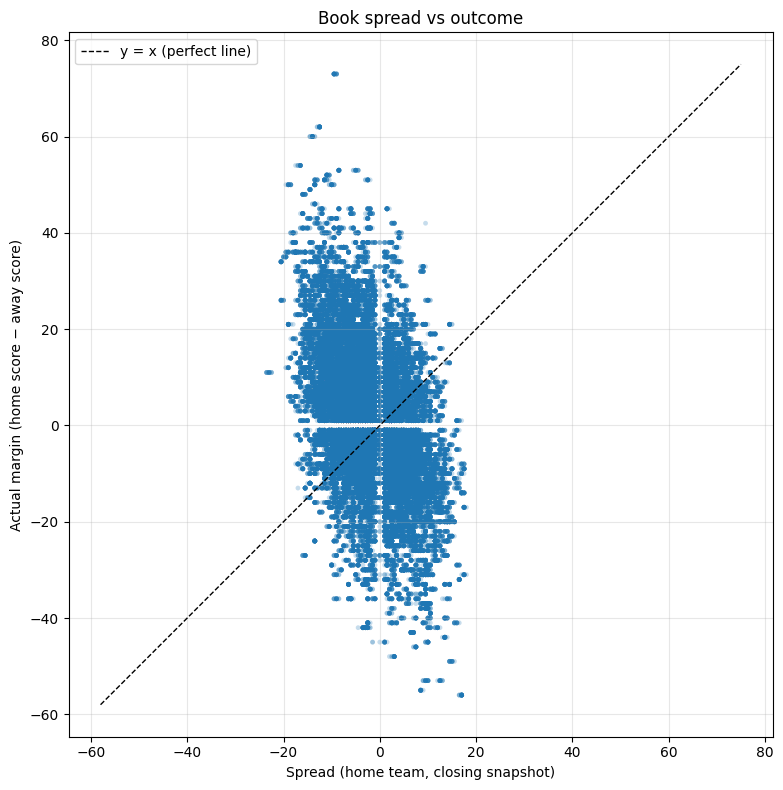

In [40]:
# Scatter: x = spread (home), y = actual margin (home − away). Perfect calibration lies on y = x.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    joined_df["spread"],
    joined_df["home_margin"],
    alpha=0.25,
    s=12,
    edgecolors="none",
)
lims = [
    min(joined_df["spread"].min(), joined_df["home_margin"].min()) - 2,
    max(joined_df["spread"].max(), joined_df["home_margin"].max()) + 2,
]
ax.plot(lims, lims, "k--", lw=1, label="y = x (perfect line)")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Spread (home team, closing snapshot)")
ax.set_ylabel("Actual margin (home score − away score)")
ax.set_title("Book spread vs outcome")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


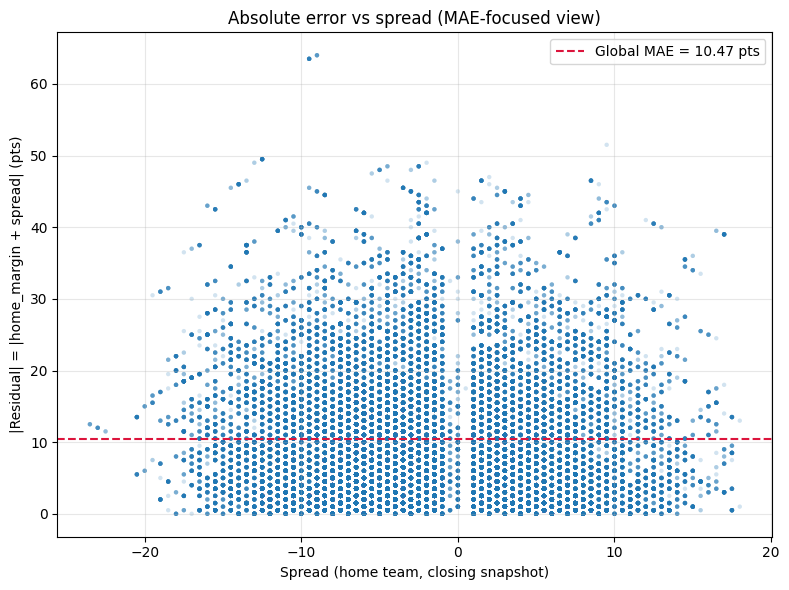

In [41]:
# Same games as above, but y = |residual| (absolute cover-margin error). MAE is the mean of y.
# Horizontal line: global MAE across all (game × book) rows.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    joined_df["spread"],
    joined_df["abs_residual"],
    alpha=0.2,
    s=10,
    edgecolors="none",
)
ax.axhline(benchmark_mae, color="crimson", linestyle="--", lw=1.5, label=f"Global MAE = {benchmark_mae:.2f} pts")
ax.set_xlabel("Spread (home team, closing snapshot)")
ax.set_ylabel("|Residual| = |home_margin + spread| (pts)")
ax.set_title("Absolute error vs spread (MAE-focused view)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

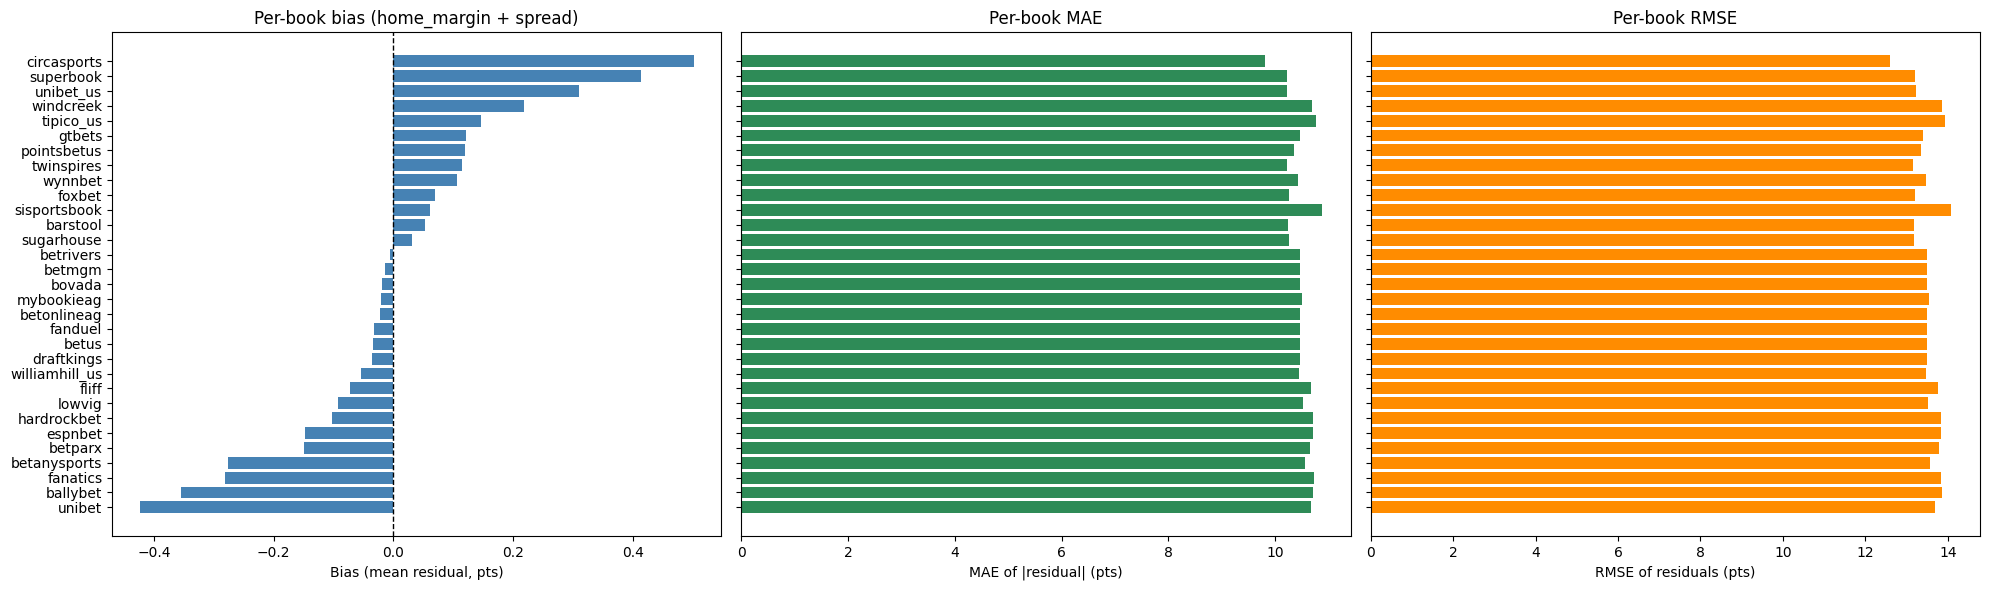

In [ ]:
# Visualize per-book bias, MAE, and RMSE side by side to compare books.

# Only include books with enough games to be meaningful.
min_games = 500
plot_df = per_book_error.loc[per_book_error["n"] >= min_games].copy()
plot_df = plot_df.sort_values("bias")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Bias bar plot (mean signed residual per book).
axes[0].barh(plot_df["bookmaker_key"], plot_df["bias"], color="steelblue")
axes[0].axvline(0.0, color="k", linestyle="--", linewidth=1)
axes[0].set_xlabel("Bias (mean residual, pts)")
axes[0].set_title("Per-book bias (home_margin + spread)")

# MAE bar plot (mean |residual| per book).
axes[1].barh(plot_df["bookmaker_key"], plot_df["mae"], color="seagreen")
axes[1].set_xlabel("MAE of |residual| (pts)")
axes[1].set_title("Per-book MAE")

# RMSE bar plot.
axes[2].barh(plot_df["bookmaker_key"], plot_df["rmse"], color="darkorange")
axes[2].set_xlabel("RMSE of residuals (pts)")
axes[2].set_title("Per-book RMSE")

plt.tight_layout()
plt.show()

In [43]:
# Global bias, MAE, and RMSE from residuals.
# residual = home_margin + spread (cover margin; home-side perspective).
#
# Bias = E[residual] (signed average cover margin).
# MAE = E[|residual|] (typical magnitude of miss, ignoring sign).
# RMSE = sqrt(E[residual^2]) (penalizes large misses more than MAE).
#
# Classical estimator bias for predicting margin with (-spread): E[-spread] − E[margin] = -E[residual].

global_bias = float(joined_df["residual"].mean())
global_mae = float(joined_df["abs_residual"].mean())
global_rmse = float(np.sqrt((joined_df["residual"] ** 2).mean()))

print(f"Global bias (E[residual]): {global_bias:.4f} pts")
print(f"Global MAE (E[|residual|]): {global_mae:.4f} pts")
print(f"Global RMSE: {global_rmse:.4f} pts")

Global bias (E[residual]): 0.0036 pts
Global MAE (E[|residual|]): 10.4717 pts
Global RMSE: 13.5021 pts
